# Reconnaissance d'entites nommees (NER) pour le Wolof

**Projet NLP — corpus MasakhaNER Wolof**

Ce notebook met en place un systeme de NER pour le wolof par *fine-tuning*
d'un transformer multilingue pre-entraine.

**Plan :**
1. **Phase 1 — Exploration** des donnees (comprendre le corpus)
2. **Phase 2 — Pipeline** (tokenization + alignement des labels sur les sous-mots)
3. **Phase 3 — Fine-tuning** *(a venir)*
4. **Phase 4 — Evaluation** au niveau entite (F1 via seqeval) *(a venir)*
5. **Phase 5 — Comparaison de modeles** *(a venir)*
6. **Phase 6 — Application Streamlit** *(a venir)*

> **Tache :** classification de tokens (*token classification*) avec schema
> **BIO**. Chaque mot recoit une etiquette parmi
> `O, B-PER, I-PER, B-LOC, I-LOC, B-DATE, I-DATE, B-ORG, I-ORG`.


## Phase 0 — Installation et donnees (Colab)

Executez cette cellule sur Colab pour installer les dependances. Puis
**televersez** les trois fichiers `train.txt`, `dev.txt`, `test.txt`
(menu fichiers de Colab, ou `files.upload()`).

Les fichiers sont au format **CoNLL** : un token et son etiquette par ligne
(separes par une tabulation ou un espace), phrases separees par une ligne vide.


In [2]:

import os
os.environ["USE_TF"] = "0"       
os.environ["USE_FLAX"] = "0"     
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [5]:
import statistics
from collections import Counter

# Verification de la presence des fichiers
for f in ["train.txt", "dev.txt", "test.txt"]:
    print(f, "->", "OK" if os.path.exists(f) else "MANQUANT")


train.txt -> OK
dev.txt -> OK
test.txt -> OK


## Phase 1 - Exploration des donnees

Objectif : comprendre finement le corpus et recolter les chiffres qui
justifient nos choix techniques (et nourrissent la presentation).


### 1.1 - Le parseur CoNLL

Fonction socle reutilisee partout : elle transforme le fichier texte en une
liste de phrases `{"tokens": [...], "labels": [...]}`.


In [6]:
def read_conll(path):
    """Lit un fichier CoNLL -> liste de {"tokens": [...], "labels": [...]}."""
    sentences = []
    tokens, labels = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.strip() == "":
                if tokens:
                    sentences.append({"tokens": tokens, "labels": labels})
                    tokens, labels = [], []
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            tokens.append(parts[0])
            labels.append(parts[-1])
    if tokens:
        sentences.append({"tokens": tokens, "labels": labels})
    return sentences


def extract_entities(labels):
    """Reconstruit les entites (type, debut, fin) a partir d'une sequence BIO.
    Sert a compter les VRAIES entites (niveau entite = ce qu'on evalue)."""
    entities, current, start = [], None, None
    for i, lab in enumerate(labels):
        if lab == "O":
            if current is not None:
                entities.append((current, start, i - 1)); current = None
        elif lab.startswith("B-"):
            if current is not None:
                entities.append((current, start, i - 1))
            current, start = lab[2:], i
        elif lab.startswith("I-"):
            t = lab[2:]
            if current != t:
                if current is not None:
                    entities.append((current, start, i - 1))
                current, start = t, i
        else:
            current = None
    if current is not None:
        entities.append((current, start, len(labels) - 1))
    return entities


data = {s: read_conll(f"{s}.txt") for s in ["train", "dev", "test"]}
print("Chargement termine.")

Chargement termine.


### 1.2 - Volume de chaque split

In [7]:
for s in ["train", "dev", "test"]:
    n_sent = len(data[s])
    n_tok = sum(len(x["tokens"]) for x in data[s])
    print(f"{s:5s} : {n_sent:5d} phrases | {n_tok:6d} tokens")

train :  1871 phrases |  36805 tokens
dev   :   267 phrases |   4384 tokens
test  :   539 phrases |  11682 tokens


### 1.3 - Distribution des etiquettes (niveau *token*)

On s'attend a un fort desequilibre : la classe `O` (mots hors entite) domine.


In [8]:
for s in ["train", "dev", "test"]:
    c = Counter(l for x in data[s] for l in x["labels"])
    total = sum(c.values())
    print(f"\n-- {s} -- (O = {100*c['O']/total:.1f}% des tokens)")
    for lab, n in c.most_common():
        print(f"   {lab:8s} {n:6d}  ({100*n/total:5.2f}%)")


-- train -- (O = 94.1% des tokens)
   O         34648  (94.14%)
   B-LOC       566  ( 1.54%)
   B-PER       522  ( 1.42%)
   I-PER       440  ( 1.20%)
   B-ORG       179  ( 0.49%)
   I-DATE      170  ( 0.46%)
   B-DATE      130  ( 0.35%)
   I-ORG       129  ( 0.35%)
   I-LOC        21  ( 0.06%)

-- dev -- (O = 96.5% des tokens)
   O          4231  (96.51%)
   B-LOC        59  ( 1.35%)
   B-PER        33  ( 0.75%)
   I-PER        28  ( 0.64%)
   B-ORG        11  ( 0.25%)
   I-ORG         6  ( 0.14%)
   B-DATE        6  ( 0.14%)
   I-DATE        5  ( 0.11%)
   I-LOC         5  ( 0.11%)

-- test -- (O = 92.5% des tokens)
   O         10807  (92.51%)
   B-LOC       211  ( 1.81%)
   I-PER       193  ( 1.65%)
   B-PER       176  ( 1.51%)
   I-DATE      153  ( 1.31%)
   B-DATE       70  ( 0.60%)
   B-ORG        55  ( 0.47%)
   I-ORG        13  ( 0.11%)
   I-LOC         4  ( 0.03%)


### 1.4 - Distribution des entites (niveau *entite*)

C'est le niveau auquel on **evalue** le modele. Les types rares seront les
plus difficiles a apprendre.


In [9]:
for s in ["train", "dev", "test"]:
    ents = [e for x in data[s] for e in extract_entities(x["labels"])]
    c = Counter(t for t, _, _ in ents)
    print(f"\n-- {s} -- ({len(ents)} entites)")
    for t, n in c.most_common():
        print(f"   {t:6s} {n:5d}")


-- train -- (1397 entites)
   LOC      566
   PER      522
   ORG      179
   DATE     130

-- dev -- (109 entites)
   LOC       59
   PER       33
   ORG       11
   DATE       6

-- test -- (512 entites)
   LOC      211
   PER      176
   DATE      70
   ORG       55


### 1.5 - Longueur des phrases (pour fixer `max_length`)

In [10]:
for s in ["train", "dev", "test"]:
    lens = [len(x["tokens"]) for x in data[s]]
    print(f"{s:5s} : min={min(lens)}  max={max(lens)}  "
          f"moy={statistics.mean(lens):.1f}  mediane={statistics.median(lens)}")

train : min=2  max=83  moy=19.7  mediane=18
dev   : min=2  max=52  moy=16.4  mediane=14
test  : min=2  max=93  moy=21.7  mediane=18


### 1.6 - Coherence BIO et mots inconnus (OOV)

Deux verifications importantes : le BIO est-il propre ? et quelle proportion
du vocabulaire de test est absente du train ?


In [11]:
# Coherence BIO : un I-X doit suivre B-X ou I-X du meme type
for s in ["train", "dev", "test"]:
    bad = 0
    for x in data[s]:
        prev = "O"
        for lab in x["labels"]:
            if lab.startswith("I-"):
                t = lab[2:]
                if prev not in (f"B-{t}", f"I-{t}"):
                    bad += 1
            prev = lab
    print(f"{s:5s} : {bad} transitions I- incoherentes")

# Taux de mots inconnus (OOV) test vs train
vocab_train = {t.lower() for x in data["train"] for t in x["tokens"]}
vocab_test = {t.lower() for x in data["test"] for t in x["tokens"]}
oov = vocab_test - vocab_train
print(f"\nOOV : {len(oov)} mots du test absents du train "
      f"({100*len(oov)/len(vocab_test):.1f}% du vocab test)")

train : 0 transitions I- incoherentes
dev   : 0 transitions I- incoherentes
test  : 0 transitions I- incoherentes

OOV : 1152 mots du test absents du train (49.4% du vocab test)


### 1.7 - Graphiques pour la presentation

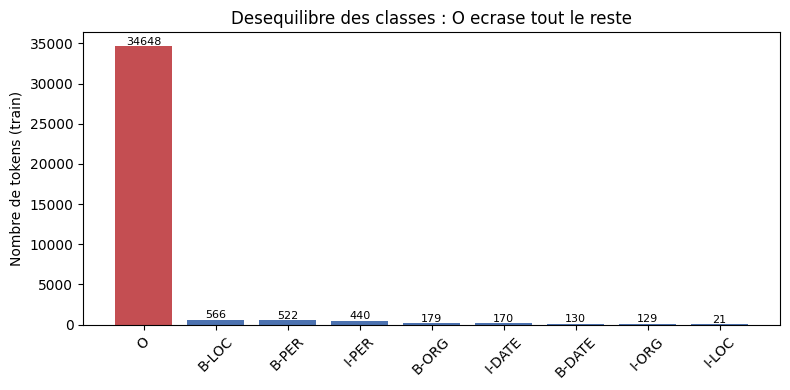

In [12]:
import matplotlib.pyplot as plt

# Desequilibre des classes (train)
c = Counter(l for x in data["train"] for l in x["labels"])
labels_sorted = ["O"] + sorted((k for k in c if k != "O"),
                               key=c.get, reverse=True)
vals = [c[l] for l in labels_sorted]
plt.figure(figsize=(8, 4))
bars = plt.bar(labels_sorted, vals,
               color=["#C44E52"] + ["#4C72B0"] * (len(labels_sorted) - 1))
plt.title("Desequilibre des classes : O ecrase tout le reste")
plt.ylabel("Nombre de tokens (train)")
plt.xticks(rotation=45)
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v+200, str(v), ha="center", fontsize=8)
plt.tight_layout(); plt.show()

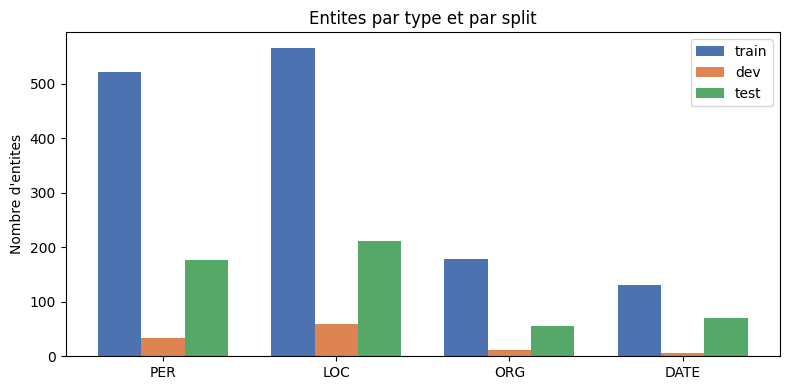

In [13]:
# Distribution des entites par type et par split
types = ["PER", "LOC", "ORG", "DATE"]
colors = {"train": "#4C72B0", "dev": "#DD8452", "test": "#55A868"}
width, x = 0.25, range(len(types))
plt.figure(figsize=(8, 4))
for i, s in enumerate(["train", "dev", "test"]):
    ents = [e for r in data[s] for e in extract_entities(r["labels"])]
    cc = Counter(t for t, _, _ in ents)
    plt.bar([p + i*width for p in x], [cc[t] for t in types], width,
            label=s, color=colors[s])
plt.xticks([p + width for p in x], types)
plt.ylabel("Nombre d'entites"); plt.title("Entites par type et par split")
plt.legend(); plt.tight_layout(); plt.show()

### Bilan de la Phase 1

- **Corpus petit** (~1900 phrases) - le *fine-tuning* d'un modele pre-entraine
  est indispensable (impossible d'entrainer de zero).
- **Fort desequilibre** (~94 % de `O`) - l'accuracy est trompeuse, d'ou
  l'evaluation au **F1 niveau entite**.
- **ORG et DATE rares** → seront les types les plus difficiles.
- **~49 % de mots inconnus** en test - un modele a **sous-mots** pre-entraine
  est le meilleur choix (il gere les mots jamais vus).
- **BIO propre** (0 incoherence) - pas de nettoyage necessaire.


## Phase 2 - Pipeline de donnees

On transforme phrases + labels en tenseurs pour le transformer, en gerant
**l'alignement labels - sous-mots** (le point technique critique).


### 2.1 - Correspondance label - entier

Le modele manipule des entiers, pas des chaines. On fige une table utilisee
dans **tout** le projet (sinon les etiquettes se decalent).


In [14]:
LABELS = ["O", "B-PER", "I-PER", "B-LOC", "I-LOC",
          "B-DATE", "I-DATE", "B-ORG", "I-ORG"]
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for l, i in label2id.items()}
print(label2id)

{'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-LOC': 3, 'I-LOC': 4, 'B-DATE': 5, 'I-DATE': 6, 'B-ORG': 7, 'I-ORG': 8}


### 2.2 - Construction du `DatasetDict` HuggingFace

In [15]:
from datasets import Dataset, DatasetDict

def load_split(path):
    sents = read_conll(path)
    return Dataset.from_dict({
        "tokens":  [s["tokens"] for s in sents],
        "ner_tags": [[label2id[l] for l in s["labels"]] for s in sents],
    })

ds = DatasetDict({
    "train":      load_split("train.txt"),
    "validation": load_split("dev.txt"),
    "test":       load_split("test.txt"),
})
print(ds)
print("\nExemple :", ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 1871
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 267
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 539
    })
})

Exemple : {'tokens': ['SAFIYETU', 'BÉEY', 'Céy', 'Koronaa', '!'], 'ner_tags': [1, 2, 0, 0, 0]}


### 2.3 - Chargement du tokenizer

`Davlan/afro-xlmr-base` est pre-entraine sur des langues africaines dont le
wolof - c'est le modele de reference du benchmark MasakhaNER. On peut aussi
tester `xlm-roberta-base` pour comparer.


In [1]:
os.environ["HF_HUB_DISABLE_XET"] = "1"
from transformers import AutoTokenizer

MODEL_NAME = "Davlan/afro-xlmr-base"   # alternative : "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Illustration du decoupage en sous-mots sur un mot wolof
mot = "SAFIYETU"
print(mot, "-", tokenizer.tokenize(mot))

NameError: name 'os' is not defined

### 2.4 - Alignement des labels sur les sous-mots (fonction clef)

Regle : le **1er** sous-mot d'un mot recoit le vrai label ; les sous-mots
suivants et les tokens speciaux recoivent **-100** (ignore par la fonction
de cout).


In [17]:
def tokenize_and_align_labels(examples, max_length=256,
                              label_all_subwords=False):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=max_length,
        is_split_into_words=True,   # on donne des MOTS deja separes
    )
    all_labels = []
    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous, label_ids = None, []
        for wid in word_ids:
            if wid is None:                 # CLS / SEP / PAD
                label_ids.append(-100)
            elif wid != previous:           # 1er sous-mot du mot
                label_ids.append(labels[wid])
            else:                           # sous-mot de continuation
                label_ids.append(labels[wid] if label_all_subwords else -100)
            previous = wid
        all_labels.append(label_ids)
    tokenized["labels"] = all_labels
    return tokenized

tokenized_ds = ds.map(tokenize_and_align_labels, batched=True,
                      remove_columns=ds["train"].column_names)
print(tokenized_ds)

Map:   0%|          | 0/1871 [00:00<?, ? examples/s]

Map:   0%|          | 0/267 [00:00<?, ? examples/s]

Map:   0%|          | 0/539 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1871
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 267
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 539
    })
})


### 2.5 - Verification : on inspecte un exemple aligne

In [18]:
ex = ds["train"][0]
enc = tokenizer(ex["tokens"], is_split_into_words=True)
out = tokenize_and_align_labels({"tokens": [ex["tokens"]],
                                 "ner_tags": [ex["ner_tags"]]})

sub_tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
word_ids = enc.word_ids()
aligned = out["labels"][0]

print(f"{'sous-mot':<15}{'word_id':<9}{'label'}")
print("-" * 34)
for st, wid, lab in zip(sub_tokens, word_ids, aligned):
    lab_str = "-100" if lab == -100 else id2label[lab]
    print(f"{st:<15}{str(wid):<9}{lab_str}")

sous-mot       word_id  label
----------------------------------
<s>            None     -100
▁              0        B-PER
SAF            0        -100
IYE            0        -100
TU             0        -100
▁B             1        I-PER
É              1        -100
EY             1        -100
▁Cé            2        O
y              2        -100
▁Koro          3        O
na             3        -100
a              3        -100
▁!             4        O
</s>           None     -100


**Lecture attendue :** un mot decoupe en plusieurs sous-mots ne garde son
etiquette que sur le premier morceau ; les autres, ainsi que `<s>`/`</s>`,
portent `-100` et n'entrent pas dans le calcul de la perte.

### Prochaine etape - Phase 3 (fine-tuning)
On ajoutera un `DataCollatorForTokenClassification` (padding dynamique par lot),
on chargera `AutoModelForTokenClassification` avec `num_labels=9` et nos tables
`label2id`/`id2label`, puis on entrainera avec le `Trainer` en suivant le
**F1 niveau entite** (seqeval) sur la validation.


In [19]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [20]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
)

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at Davlan/afro-xlmr-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
import numpy as np
import evaluate

seqeval = evaluate.load("seqeval")

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)

    # On ne garde que les positions valides (label != -100)
    true_predictions = [
        [id2label[p] for p, l in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]
    true_labels = [
        [id2label[l] for p, l in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions,
                              references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall":    results["overall_recall"],
        "f1":        results["overall_f1"],
        "accuracy":  results["overall_accuracy"],
    }

In [22]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="afro-xlmr-wolof-ner",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=15,
    weight_decay=0.01,
    eval_strategy="epoch",          # transformers < 4.41 : evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
)

In [23]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,     # transformers < 5 : utiliser tokenizer=tokenizer
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.176500,0.097984,0.479592,0.431193,0.454106,0.976734
2,0.119900,0.070822,0.579832,0.633028,0.605263,0.982892
3,0.073700,0.067050,0.636364,0.642202,0.639269,0.984261
4,0.057100,0.059564,0.684211,0.715596,0.699552,0.986086
5,0.037100,0.065615,0.712963,0.706422,0.709677,0.986086
6,0.035600,0.059391,0.773196,0.688073,0.728155,0.987682
7,0.025900,0.065176,0.732143,0.752294,0.742081,0.987682
8,0.022700,0.065593,0.764151,0.743119,0.753488,0.988823
9,0.016200,0.073926,0.692308,0.743119,0.716814,0.987454
10,0.009700,0.073290,0.719626,0.706422,0.712963,0.987682


C:\Users\LENOVO LEGION\AppData\Local\Programs\Python\Python312\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


TrainOutput(global_step=1287, training_loss=0.0667832345117778, metrics={'train_runtime': 450.602, 'train_samples_per_second': 62.283, 'train_steps_per_second': 3.895, 'total_flos': 883863633486384.0, 'train_loss': 0.0667832345117778, 'epoch': 11.0})

In [24]:
trainer.save_model("afro-xlmr-wolof-ner")
tokenizer.save_pretrained("afro-xlmr-wolof-ner")
print("Modele sauvegarde dans ./afro-xlmr-wolof-ner")

Modele sauvegarde dans ./afro-xlmr-wolof-ner


## Phase 4 - Evaluation sur le test

On mesure le meilleur modele sur les 539 phrases de **test** (jamais vues).
Trois angles :
1. le **F1 global** et le **rapport par type d'entite** (seqeval) ;
2. une **matrice de confusion** pour voir quelles etiquettes sont confondues ;
3. une **analyse qualitative** sur quelques phrases.

In [25]:
import numpy as np

pred_output = trainer.predict(tokenized_ds["test"])
logits = pred_output.predictions
labels = pred_output.label_ids
preds = np.argmax(logits, axis=-1)

# Conversion en etiquettes texte, positions -100 retirees
true_predictions = [
    [id2label[p] for p, l in zip(pred, lab) if l != -100]
    for pred, lab in zip(preds, labels)
]
true_labels = [
    [id2label[l] for p, l in zip(pred, lab) if l != -100]
    for pred, lab in zip(preds, labels)
]
print("Nombre de phrases evaluees :", len(true_labels))

Nombre de phrases evaluees : 539


In [26]:
from seqeval.metrics import classification_report, f1_score

print("F1 global (niveau entite) :",
      round(f1_score(true_labels, true_predictions), 4))
print()
print(classification_report(true_labels, true_predictions,
                            digits=4, zero_division=0))

F1 global (niveau entite) : 0.6254

              precision    recall  f1-score   support

        DATE     0.3111    0.2000    0.2435        70
         LOC     0.8421    0.7583    0.7980       211
         ORG     0.5778    0.4727    0.5200        55
         PER     0.5596    0.6136    0.5854       176

   micro avg     0.6512    0.6016    0.6254       512
   macro avg     0.5726    0.5112    0.5367       512
weighted avg     0.6440    0.6016    0.6192       512



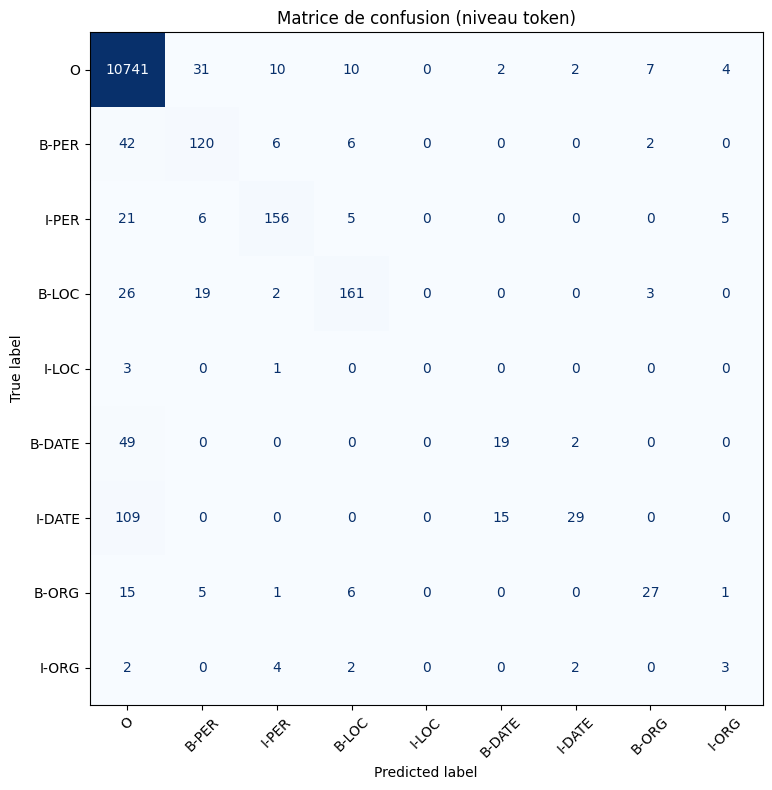

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

flat_true = [l for seq in true_labels for l in seq]
flat_pred = [p for seq in true_predictions for p in seq]

cm = confusion_matrix(flat_true, flat_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
    ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False, values_format="d")
plt.title("Matrice de confusion (niveau token)")
plt.savefig("Matrice de confusion (niveau token).png")
plt.tight_layout(); plt.show()

In [28]:
from transformers import pipeline

ner_pipe = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple",   # regroupe les sous-mots en entites
)

# Phrases de test contenant au moins une entite (label != O)
riches = [i for i in range(len(ds["test"]))
          if any(t != label2id["O"] for t in ds["test"][i]["ner_tags"])]

for i in riches[:5]:
    phrase = " ".join(ds["test"][i]["tokens"])
    print("Phrase :", phrase)
    for ent in ner_pipe(phrase):
        print(f"   {ent['entity_group']:5s} | {ent['word']}  ({ent['score']:.2f})")
    print()

Device set to use cuda:0


Phrase : Abdulaay Sekk
   PER   | Abdul  (0.97)
   PER   | aay Se  (0.81)

Phrase : Tënub Léwopóol II ba nekk ca déngaleereb ngàngunaay bu Burusel la ñu daax cuub bu xonq ci tallata jee ci ngoon .
   PER   | Léwopóol II  (0.81)
   PER   | usel  (0.52)

Phrase : Ki jëf jëf ju ni mel nag mooy bañkat bii te di ab bindkat di Théophile de Giraud muy tuumaal Lewopóol II , ne raykatu nit bu mag a mag la ca ba muy mbéefar réewum Kóngoo . Bindkat boobu te di ab bañkat , dëkk ca Belsig moo yéeg ba ca kaw tën ba , jaare ko ci ag buum , bi 15i waxtu jotee ci talaata ji laataa muy sotti cuub bu xonq boobu ca kaw tën ba ngir wane deret ju bari ja waa jooju tuur .
   PER   | Th  (0.87)
   ORG   | ophile de Giraud  (0.73)
   PER   | Lewopóol II  (0.83)
   LOC   | K  (0.99)
   LOC   | ón  (0.53)
   LOC   | Bel  (0.99)
   DATE  | tala  (0.84)

Phrase : Bu nu sukkandikoo ci moom , Lewopóol ll , ab yongkat la bu ray nit ñu bari ba waral kenn waru koo jàppe jàmbaar ju ñuy sargal ca réew ma .
   PER   | Lew

## Phase 5 - Comparaison de modeles

Objectif : mesurer l'**apport du pre-entrainement africain**. On compare
`Davlan/afro-xlmr-base` (pre-entraine sur des langues africaines dont le wolof)
a `xlm-roberta-base` (multilingue "generaliste", sans focus africain).

**Rigueur experimentale :** on garde *tout* identique - memes donnees, memes
hyperparametres, meme fonction d'alignement, meme early stopping. **Seul le
modele de base change.** Ainsi, toute difference de F1 est attribuable au
pre-entrainement, pas a un autre facteur. C'est le point methodologique clef.

### 5.1 - Une fonction d'experience reutilisable

On encapsule tout le pipeline (tokenisation, entrainement, evaluation test)
dans une fonction. Chaque modele a son propre tokenizer, donc la tokenisation
est refaite a l'interieur. La fonction renvoie les F1 (global + par type).

In [29]:
import numpy as np
from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                          DataCollatorForTokenClassification, TrainingArguments,
                          Trainer, EarlyStoppingCallback)
from seqeval.metrics import classification_report, f1_score

def run_experiment(model_name, num_epochs=15):
    tok = AutoTokenizer.from_pretrained(model_name)

    def tokenize_align(examples):
        enc = tok(examples["tokens"], truncation=True, max_length=256,
                  is_split_into_words=True)
        all_labels = []
        for i, labs in enumerate(examples["ner_tags"]):
            word_ids = enc.word_ids(batch_index=i)
            prev, ids = None, []
            for wid in word_ids:
                if wid is None:      ids.append(-100)
                elif wid != prev:    ids.append(labs[wid])
                else:                ids.append(-100)
                prev = wid
            all_labels.append(ids)
        enc["labels"] = all_labels
        return enc

    tds = ds.map(tokenize_align, batched=True,
                 remove_columns=ds["train"].column_names)

    model = AutoModelForTokenClassification.from_pretrained(
        model_name, num_labels=len(LABELS),
        id2label=id2label, label2id=label2id)

    args = TrainingArguments(
        output_dir=f"out-{model_name.split('/')[-1]}",
        learning_rate=2e-5,
        per_device_train_batch_size=16, per_device_eval_batch_size=16,
        num_train_epochs=num_epochs, weight_decay=0.01,
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="f1",
        greater_is_better=True, logging_steps=50, report_to="none",
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=tds["train"], eval_dataset=tds["validation"],
        processing_class=tok,
        data_collator=DataCollatorForTokenClassification(tokenizer=tok),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer.train()

    # Evaluation sur le test
    out = trainer.predict(tds["test"])
    preds = np.argmax(out.predictions, axis=-1)
    labs = out.label_ids
    tp = [[id2label[p] for p, l in zip(pr, la) if l != -100]
          for pr, la in zip(preds, labs)]
    tl = [[id2label[l] for p, l in zip(pr, la) if l != -100]
          for pr, la in zip(preds, labs)]

    rep = classification_report(tl, tp, digits=4, zero_division=0,
                                output_dict=True)
    return {"f1_global": f1_score(tl, tp), "report": rep}

In [32]:
## import gc, torch
import gc, torch
MODELES = ["Davlan/afro-xlmr-base", "xlm-roberta-base"]
resultats = {}

for nom in MODELES:
    print("\n" + "=" * 55)
    print("ENTRAINEMENT :", nom)
    print("=" * 55)
    resultats[nom] = run_experiment(nom)
    gc.collect()
    torch.cuda.empty_cache()   # libere la memoire GPU avant le modele suivant

print("\nTermine.")


ENTRAINEMENT : Davlan/afro-xlmr-base


Map:   0%|          | 0/1871 [00:00<?, ? examples/s]

Map:   0%|          | 0/267 [00:00<?, ? examples/s]

Map:   0%|          | 0/539 [00:00<?, ? examples/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at Davlan/afro-xlmr-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Map:   0%|          | 0/539 [00:00<?, ? examples/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.168400,0.084505,0.582418,0.486239,0.530000,0.980839
2,0.102000,0.068598,0.657658,0.669725,0.663636,0.984717
3,0.060900,0.072003,0.606838,0.651376,0.628319,0.982208
4,0.048800,0.058782,0.764151,0.743119,0.753488,0.986770
5,0.030000,0.063192,0.723214,0.743119,0.733032,0.987226
6,0.029700,0.063664,0.795918,0.715596,0.753623,0.988595
7,0.021500,0.063455,0.769231,0.733945,0.751174,0.987682
8,0.013000,0.071482,0.756757,0.770642,0.763636,0.988367
9,0.012600,0.063545,0.774775,0.788991,0.781818,0.988823
10,0.007100,0.067517,0.788462,0.752294,0.769953,0.988823


C:\Users\LENOVO LEGION\AppData\Local\Programs\Python\Python312\Lib\site-packages\seqeval\metrics\v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Termine.


In [33]:
import pandas as pd

lignes = []
for nom, res in resultats.items():
    r = res["report"]
    lignes.append({
        "modele":    nom.split("/")[-1],
        "F1 global": round(res["f1_global"], 4),
        "PER":  round(r.get("PER",  {}).get("f1-score", 0), 3),
        "LOC":  round(r.get("LOC",  {}).get("f1-score", 0), 3),
        "ORG":  round(r.get("ORG",  {}).get("f1-score", 0), 3),
        "DATE": round(r.get("DATE", {}).get("f1-score", 0), 3),
    })

df = pd.DataFrame(lignes)
print(df.to_string(index=False))

          modele  F1 global   PER   LOC   ORG  DATE
  afro-xlmr-base     0.6083 0.611 0.791 0.336 0.222
xlm-roberta-base     0.6059 0.585 0.774 0.389 0.339


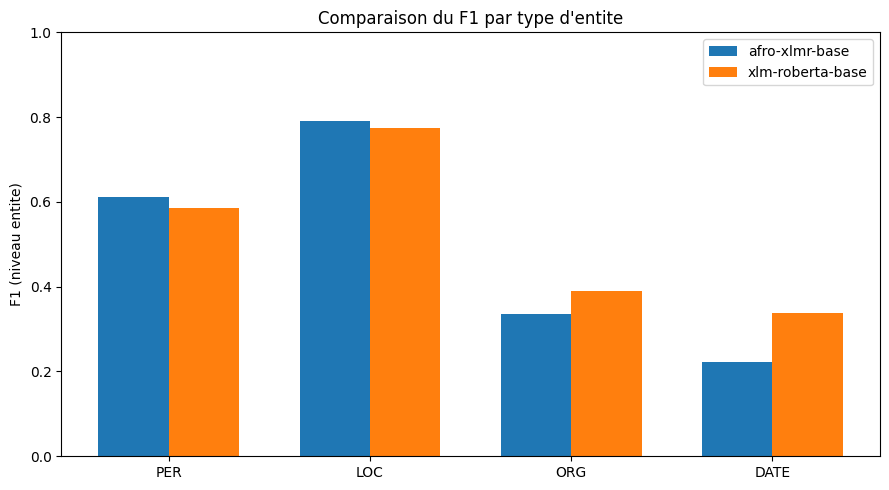

In [34]:
import matplotlib.pyplot as plt

types = ["PER", "LOC", "ORG", "DATE"]
noms = [nom.split("/")[-1] for nom in MODELES]
width, x = 0.35, range(len(types))

plt.figure(figsize=(9, 5))
for i, nom in enumerate(MODELES):
    r = resultats[nom]["report"]
    vals = [r.get(t, {}).get("f1-score", 0) for t in types]
    plt.bar([p + i*width for p in x], vals, width, label=nom.split("/")[-1])
plt.xticks([p + width/2 for p in x], types)
plt.ylabel("F1 (niveau entite)")
plt.title("Comparaison du F1 par type d'entite")
plt.legend(); plt.ylim(0, 1); plt.tight_layout(); plt.show()